# Principal Component Analysis (PCA) (7/8/26)

---

*Codecademy — MLE Path: Unsupervised Learning (final lesson of ML Fundamentals block). Concise grad-student notes.*

## Introduction to PCA

Models get better when features are engineered to suit the question at hand. With small feature sets we can just include everything and eyeball correlations (e.g. height vs. weight). But with datasets that have **many features**, visualizing and correlating everything gets hard, and training runs into computational/complexity limits.

**Principal Component Analysis (PCA)** reduces the number of features in a dataset **without losing the information** those features carried. It does this by leveraging correlations between features to build a smaller set of new, better features.

## Laying the Groundwork: Variance = Information

PCA needs a way to measure "how much information" a feature carries. **Variance** is the starting point: a column where every row has the *same* value (e.g. `total_customers` always = 500) contains no information, no matter how many rows it has — there's nothing to distinguish observations from each other. A column with real spread in its values is informative.

Variance alone isn't sufficient though — it has to be judged relative to the feature's scale. A variance of 5 means something very different for a mean of 2 than for a mean of 100. That's what the **Coefficient of Variation (CV)** captures:

$$CV = \frac{\text{std}(x)}{\text{mean}(x)} \times 100$$

Features get effectively ranked by their CV (i.e. by how much *relative* information they carry) — PCA looks at the most-informative features first when building principal components.

*Note: the article uses a `pizza.csv` dataset (revenue, total_customers, amt_flour, amt_tomatoes, amt_cheese for pizza stores) that isn't available locally. Below I regenerate a synthetic version matching the article's reported covariance matrix and CVs, so the code runs and reproduces the same pattern of results.*

In [1]:
# Regenerate pizza.csv to match the article's reported covariance matrix / CVs
import numpy as np
import pandas as pd

np.random.seed(10)

cols = ['revenue', 'total_customers', 'amt_flour', 'amt_tomatoes', 'amt_cheese']

# covariance matrix as reported in the article
cov = np.array([
    [1.563517e+06, 31853.053820, 3713.664277, 19980.869509, 9152.568482],
    [31853.053820, 1295.096885, 105.909335, 577.443015, 256.641069],
    [3713.664277, 105.909335, 16.894551, 66.165738, 29.130750],
    [19980.869509, 577.443015, 66.165738, 500.715936, 162.221734],
    [9152.568482, 256.641069, 29.130750, 162.221734, 105.370280],
])
cv_target = np.array([10.001034, 5.138628, 9.128946, 9.926973, 6.401035])  # article's CVs
mean = np.sqrt(np.diag(cov)) / cv_target * 100  # back out means from std & CV

data = np.random.multivariate_normal(mean, cov, size=500)
df = pd.DataFrame(data, columns=cols)
df.to_csv('pizza.csv', index=False)

print(df.columns)
# -> Index(['revenue', 'total_customers', 'amt_flour', 'amt_tomatoes', 'amt_cheese'], dtype='object')

Index(['revenue', 'total_customers', 'amt_flour', 'amt_tomatoes',
       'amt_cheese'],
      dtype='object')


In [2]:
# Coefficient of Variation per feature
cv = lambda x: np.std(x, ddof=1) / np.mean(x) * 100

print(df.apply(cv))
# -> revenue, amt_tomatoes, amt_flour, amt_cheese, total_customers roughly in
#    descending CV order (matches article's stated importance ranking for PCA)

revenue            9.691787
total_customers    4.967948
amt_flour          9.256556
amt_tomatoes       9.711588
amt_cheese         6.468899
dtype: float64


### Coding exercise — `pizza_new.csv`

*Note: `pizza_new.csv` isn't available locally, so a synthetic stand-in with the same 5 columns (different random draw, so it produces a different CV ranking than the original `pizza.csv`) is generated so this exercise runs end-to-end.*

In [3]:
# Generate a synthetic pizza_new.csv stand-in (different draw than pizza.csv)
np.random.seed(42)

cols_new = ['revenue', 'total_customers', 'amt_flour', 'amt_tomatoes', 'amt_cheese']
mean_new = np.array([12000, 650, 42, 210, 150])
std_new = np.array([1800, 25, 5.5, 12, 6])
corr_new = np.array([
    [1.00, 0.75, 0.55, 0.60, 0.50],
    [0.75, 1.00, 0.45, 0.50, 0.40],
    [0.55, 0.45, 1.00, 0.60, 0.55],
    [0.60, 0.50, 0.60, 1.00, 0.65],
    [0.50, 0.40, 0.55, 0.65, 1.00],
])
cov_new = np.outer(std_new, std_new) * corr_new

data_new = np.random.multivariate_normal(mean_new, cov_new, size=500)
pd.DataFrame(data_new, columns=cols_new).to_csv('pizza_new.csv', index=False)

In [4]:
import numpy as np
import pandas as pd

# Load in new pizza dataset
df_new = pd.read_csv('pizza_new.csv')
df_new.head()

# Calculate coefficient of variance for every feature
#define function to calculate cv
cv = lambda x: np.std(x, ddof=1) / np.mean(x) * 100
print(df_new.apply(cv))

# Rank order of importance from highest to lowest (in a list)
importance_rank = df_new.apply(cv).sort_values(ascending=False).index.tolist()
print(importance_rank)

revenue            14.643304
total_customers     3.851725
amt_flour          13.122475
amt_tomatoes        5.654441
amt_cheese          3.879316
dtype: float64
['revenue', 'amt_flour', 'amt_tomatoes', 'amt_cheese', 'total_customers']


## The Math Behind PCA

**1. Data Matrix** — the dataset itself: rows = observations, columns = the features we're feeding into PCA (labels/targets are excluded).

**2. Covariance Matrix** — for every pair of features $X, Y$:

$$Cov(X,Y) = \frac{1}{n-1}\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})$$

Doing this for every feature pair gives a square, symmetric matrix. Its diagonal entries are just each feature's own variance (the same numbers we already calculated as CV inputs); the off-diagonal entries capture how features move together. In pandas this is one call: `df.cov()`.

**3. Matrix Factorization → Eigenvalues & Eigenvectors** — PCA factors the covariance matrix into a smaller matrix that still captures most of the information. The key players are **eigenvectors**: directions that don't change when a transformation is applied. Geometrically, they give directions to "rotate" the dataset in n-dimensional space so it can be viewed from a simplified perspective. **Eigenvalues** are attached to each eigenvector and describe how much variance (information) that direction accounts for.

For covariance matrix $A$, eigenvalues $\lambda$ solve:

$$\det(A - \lambda I) = 0$$

(the article works this out concretely for the 5x5 pizza covariance matrix — same equation, just bigger).

**4. Principal Components** — the eigenvectors themselves, once ranked by their eigenvalues. Each principal component is a **linear combination of all the original features**. Keeping only the top few (e.g. top 2) lets you "rotate" an n-dimensional dataset down into 2D for plotting/analysis, while retaining as much of the original variance as possible.

In [5]:
# Covariance matrix via pandas
print(df.cov())
# -> 5x5 symmetric matrix; diagonal = each feature's variance (matches article's numbers
#    since we built df from that exact covariance matrix)

                      revenue  total_customers    amt_flour  amt_tomatoes  \
revenue          1.470306e+06     29994.152088  3777.977679  19792.956282   
total_customers  2.999415e+04      1209.938863   103.415199    543.778389   
amt_flour        3.777978e+03       103.415199    17.499204     69.308434   
amt_tomatoes     1.979296e+04       543.778389    69.308434    479.477189   
amt_cheese       9.051192e+03       250.796148    31.438220    164.067875   

                  amt_cheese  
revenue          9051.191717  
total_customers   250.796148  
amt_flour          31.438220  
amt_tomatoes      164.067875  
amt_cheese        107.725520  


## Principal Components in Practice

Two features at a time are easy to eyeball (e.g. `revenue` vs. `total_customers`), and `sns.pairplot` extends that to every pairwise combination. But with 5+ features, understanding *all* the relationships at once — a 5-dimensional space — isn't something we can visualize directly. That's the problem PCA solves: rotate the whole dataset down to 2 principal components and plot those instead.

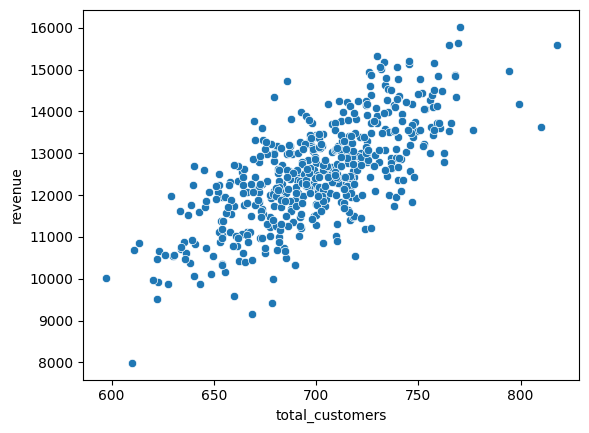

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# pairwise correlation, one pair at a time
sns.scatterplot(x='total_customers', y='revenue', data=df)
plt.show()
# -> positive correlation: more customers, more revenue

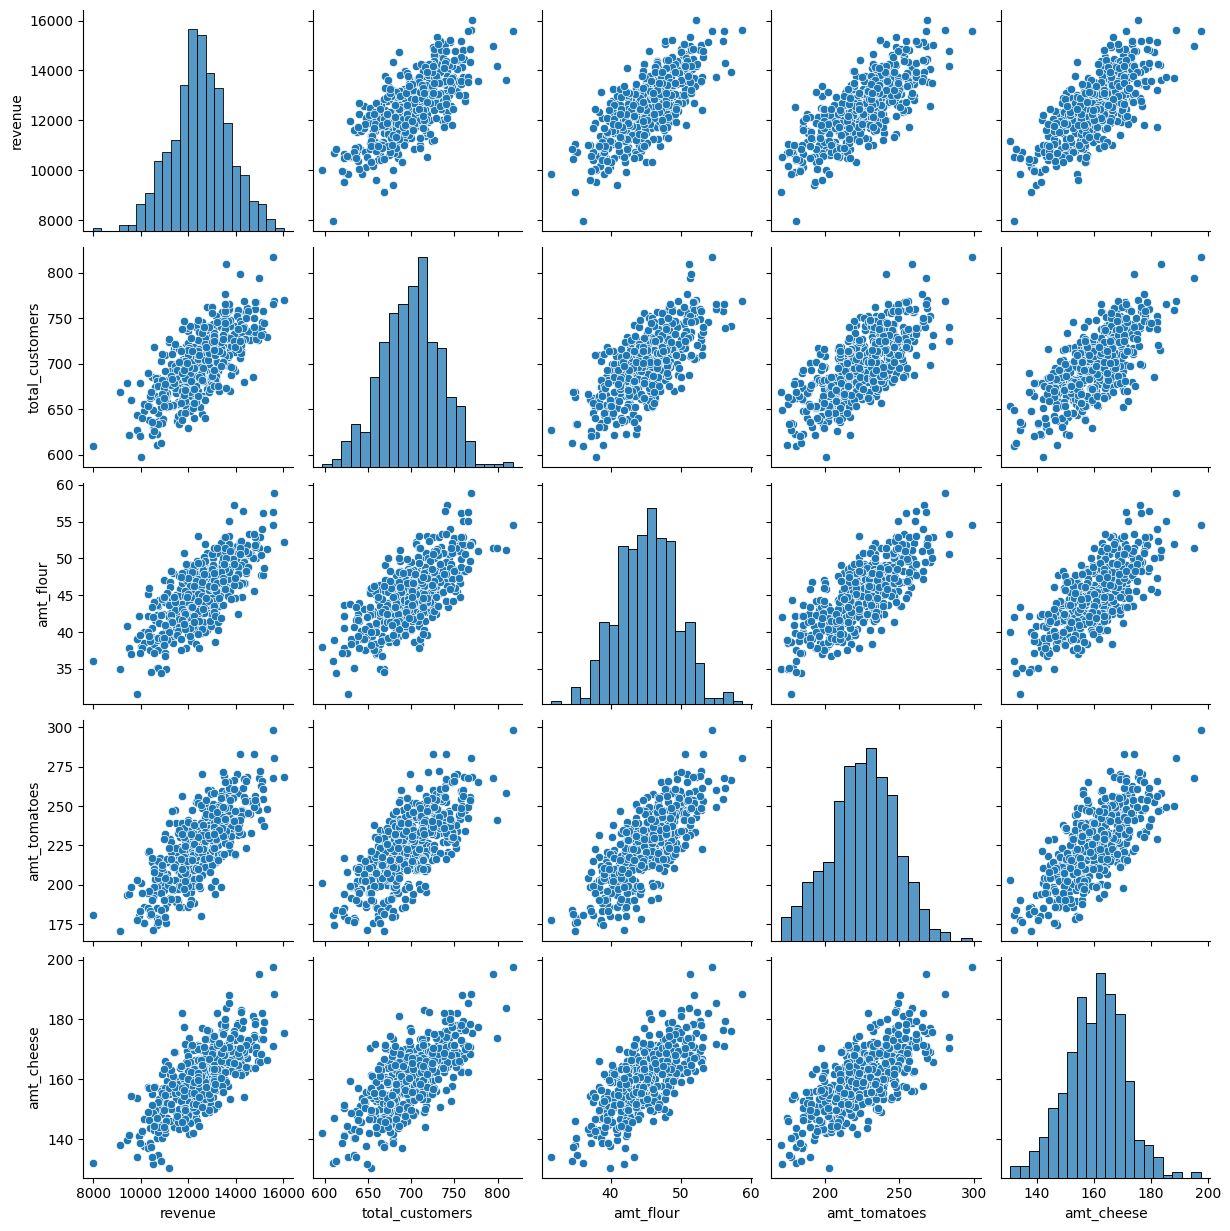

In [7]:
# all pairwise combinations at once -- gets hard to parse as feature count grows
sns.pairplot(df)
plt.show()

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_array = pca.fit_transform(df)

print(pca_array[:5])
# -> 5 rows x 2 columns: our 5 original features rotated down to 2 principal components

[[-1673.98165617   -19.13528098]
 [  892.22446572    -7.00571905]
 [ -550.07655293   -32.19743217]
 [ -565.21507703    31.10648917]
 [ 2465.29285384    46.6277538 ]]


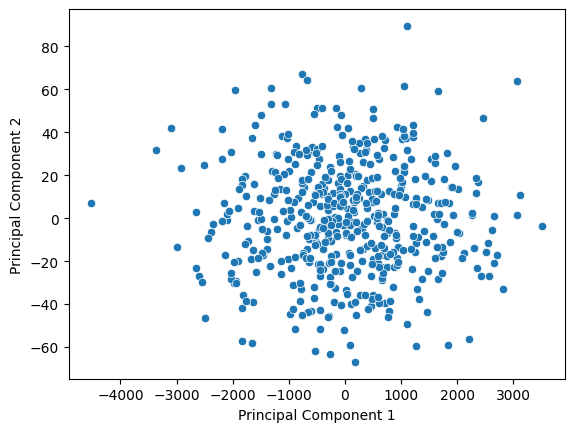

In [9]:
# plot the reduced 2D representation
sns.scatterplot(x=pca_array[:, 0], y=pca_array[:, 1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
# -> 5 original features condensed into a single 2D scatterplot

### Fill-in-the-blank recap (from the article's quiz)

> For a given dataset, we start by calculating a **covariance matrix** for all of our features.
>
> Afterwards, we perform **matrix factorization**, which will separate out the dataset and give us two results:
> 1. **eigenvectors**, also known as Principal Components, which define the direction, or "rotation", of our new data space
> 2. **eigenvalues**, which determine the magnitude of that new data space

## The How, Where, and Why of PCA

- **Dimensionality reduction for downstream models.** A high-dimensional dataset reduced to 2 (or a few) principal components is much easier to feed into forecasting models, linear regression, etc. — techniques that would be harder or slower against the full original feature set.
- **Unsupervised clustering on its own.** PCA is inherently unsupervised. Since it groups data by similarity across features (conceptually similar to k-means), setting the number of principal components to keep effectively defines groupings ("rotations") that behave like clusters. In practice, PCA is more often used as a *preprocessing* step before another clustering algorithm (to boost accuracy/speed) than as the clustering method itself.
- **Image processing.** Images carry huge amounts of information per file, which is expensive to process directly. PCA can shrink an image's feature space while reconstructing it with minimal information loss — useful for tasks like image classification.

## Q & A

**Q: What is a coefficient of variation?**

A: A normalized measure of spread that expresses standard deviation as a percentage of the mean:

$$CV = \frac{\text{std}(x)}{\text{mean}(x)} \times 100$$

Raw variance can't be compared across features with different scales/units — a variance of 5 is enormous relative to a mean of 2, but trivial relative to a mean of 100. CV fixes that by putting every feature's spread on the same relative (percentage) footing, which is what lets PCA meaningfully rank features by "how much information" they carry regardless of their original units.

**Q: What are principal components? What are the applications of eigenvectors and eigenvalues in this context?**

A: **Principal components** are new, synthetic features built as **linear combinations of all the original features**. Rather than selecting a subset of the original columns, PCA rotates the coordinate system so the new axes point in the directions of greatest variance: PC1 captures the most variance possible along a single direction, PC2 captures the most *remaining* variance orthogonal to PC1, and so on. Keeping only the top few compresses the dataset's information into far fewer dimensions.

**Eigenvectors** are exactly what the principal components *are* — each eigenvector of the covariance matrix defines one principal component's direction. Applications:
- Define the new coordinate axes (each eigenvector = one axis of the reduced space).
- Projection: the original data is dot-producted onto the top-k eigenvectors to get the reduced dataset (what `pca.fit_transform(df)` does internally).
- Orthogonality: eigenvectors of a (symmetric) covariance matrix are mutually orthogonal, so principal components end up uncorrelated — no redundant information between the new features.
- Reconstruction: multiplying back through the eigenvectors approximately reconstructs the original data, showing how much information survived compression (e.g. the pineapple image example).

**Eigenvalues** measure how much variance each corresponding eigenvector/principal component accounts for. Applications:
- Ranking components: sort eigenvectors by eigenvalue, descending, to know which principal components matter most.
- Choosing how many to keep: dividing each eigenvalue by the sum of all eigenvalues gives the "explained variance ratio" (`pca.explained_variance_ratio_` in sklearn); keep enough components to explain, e.g., 95% of total variance.
- Quantifying information loss: the eigenvalues belonging to the *dropped* components tell you exactly how much variance/information was discarded by the dimensionality reduction.

**Q: Principal Components (eigenvectors) determine — which of these? (a) behavior of new incoming data, (b) how much features vary relative to one another, (c) the importance of a particular feature, (d) the direction/rotation for a data space**

A: **(d) the direction / rotation for a data space.** Eigenvectors define the new axes the dataset gets rotated onto. (b) is what the covariance matrix captures, (c) is closer to what eigenvalues rank, and (a) describes inference with an already-fitted model, not what an eigenvector itself represents.

**Q: What does PCA applied for image processing and clustering analysis look like?**

A: **Image processing** — each pixel is a feature, so images carry huge dimensionality that's expensive to process directly. PCA reduces that feature space while preserving most of the visual information, so downstream tasks (e.g. image classification) run on a far smaller representation. The article's pineapple example reconstructs an image from its PCA eigenvectors and it looks nearly identical to the original — minimal information loss despite the dimensionality drop.

**Clustering** — PCA is inherently unsupervised, so it can surface structure in unlabeled data on its own (conceptually similar to k-means): the number of principal components kept effectively defines groupings/"rotations" that can behave like clusters. More commonly in practice, though, PCA is used as a **preprocessing step before** a dedicated clustering algorithm like k-means — stripping out noisy/redundant correlated features first tends to make the downstream clustering faster and more accurate.

**Q: What is a scree plot, and what do the plotting arguments mean?**

A: A **scree plot** is a line plot of each principal component's eigenvalue (or proportion of variance explained), ranked in descending order. The name comes from geology — "scree" is the loose rubble at the base of a slope — because the curve looks like a mountain: a steep initial drop, then a flat tail. You use it to spot the **elbow**: the point where adding more components stops meaningfully increasing explained variance, which is the practical cue for how many components to keep.

Breaking down `plt.plot(np.arange(1, len(info_prop) + 1), info_prop, 'bo-')`:
- `np.arange(1, len(info_prop) + 1)` — x-axis values. `arange`'s stop is exclusive, so `+1` is needed to include the last component; starting at 1 (not 0) numbers components the way people actually talk about "component 1, component 2, ...".
- `info_prop` — y-axis values, each component's proportion of variance explained.
- `'bo-'` — matplotlib shorthand: `b` = blue, `o` = circle markers, `-` = solid connecting line.

And the two reference lines on the cumulative plot:
- `plt.hlines(y=0.95, xmin=0, xmax=len(info_prop))` — a horizontal line at the 95%-of-variance threshold, spanning the full x-axis.
- `plt.vlines(x=n_components_95, ymin=0, ymax=1)` — a vertical line at whichever component count first crosses that threshold, spanning the full y-axis.

Together they just mark visually where the cumulative-variance curve meets the 95% target — no computation happens in the plotting calls themselves, `n_components_95` is computed separately.

**Q: What is the cumulative sum again?**

A: `np.cumsum` turns an array into a running total: each output element is the sum of itself plus every element before it. For `info_prop = [0.49, 0.33, 0.08, 0.05, 0.03, ...]`, `np.cumsum(info_prop)` gives `[0.49, 0.82, 0.90, 0.95, 0.98, ...]`.

The distinction that matters here: `info_prop[k]` answers "how much variance does component *k* explain **alone**?", while `cum_info_prop[k]` answers "how much variance do the first *k* components explain **together**?" That's exactly what's needed to answer "how many components until we hit 95% of total variance?" — walk the cumulative array until it crosses 0.95, which is what `n_components_95 = (cum_info_prop < 0.95).sum() + 1` does.

# Implementing PCA in Python

*Codecademy — MLE Path: Unsupervised Learning → Implementing PCA in Python.*

## Introduction to Implementing PCA

Goal for this lesson: implement PCA using **NumPy** and **scikit-learn**.

Recall the motivation: PCA finds a new set of features ordered by how much variation (information) they contain, so we can keep a subset of them and end up with **lower-dimensional data that still retains most of the original information**.

Plan for the lesson:
- Implement PCA step-by-step in NumPy
- Implement PCA in scikit-learn in just a few lines
- Use principal components as input features to train a machine learning model
- Visualize principal components using image data

Dataset for the next several exercises: a **dry bean dataset** — several types of dry beans separated into seven categories, described by a set of features.

## Loading the Dry Bean Dataset

Load the CSV, confirm all columns are numerical except `Class`, then split the dataset into the numerical feature matrix and the class labels — PCA only operates on the numerical **data matrix**, not the target/label column.

In [10]:
import pandas as pd

# Read the csv data as a DataFrame
df = pd.read_csv('./Dry_Beans.csv')

# Remove null and na values
df.dropna()

# 1. Print the DataFrame head
print(df.head())

# 2. Extract the numerical columns
data_matrix = df.drop(columns='Class')

# Extract the classes
classes = df['Class']

print(data_matrix)

    Area  Perimeter  MajorAxisLength  MinorAxisLength  ConvexArea  \
0  41487    815.900       299.046841       177.081490       42483   
1  41488    759.552       283.142777       186.985489       42005   
2  42012    809.770       266.700396       202.381088       43087   
3  43122    838.186       296.404589       185.657600       44074   
4  43145    799.426       273.402945       201.266886       43812   

   EquivDiameter  AspectRatio  Eccentricity    Extent  Solidity  Roundness  \
0     229.832306     1.688753      0.805826  0.689176  0.976555   0.783156   
1     229.835076     1.514250      0.750920  0.708434  0.987692   0.903686   
2     231.281949     1.317813      0.651285  0.770976  0.975050   0.805119   
3     234.317382     1.596512      0.779530  0.731986  0.978400   0.771308   
4     234.379863     1.358410      0.676813  0.766123  0.984776   0.848367   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  \
0     0.768550      0.007208      0.001551

## Implementing PCA in NumPy I

`np.linalg.eig` performs **eigendecomposition** directly, returning the eigenvalues and eigenvectors of a matrix in one call.

- **Eigenvalues** relate to how much relative variation each principal component captures.
- **Eigenvectors** (a.k.a. the **principal axes**) tell us how to rotate the data into the new features that capture that variation.

Steps:
1. Build a **correlation matrix** from `data_matrix` with `.corr()` (this lesson factors the correlation matrix rather than the covariance matrix — same idea, but pre-scaled so features are comparable regardless of units).
2. Feed it to `np.linalg.eig()` to get the eigenvalues and eigenvectors.

The heatmap of the correlation matrix below shows several pairs of dry-bean features with very high correlation (e.g. `Area`/`ConvexArea`, the various length/shape-factor measures) — exactly the kind of redundancy PCA is designed to compress away. With 16 features, `eigenvalues` comes out as 16 numbers and `eigenvectors` as 16 vectors of 16 values each.

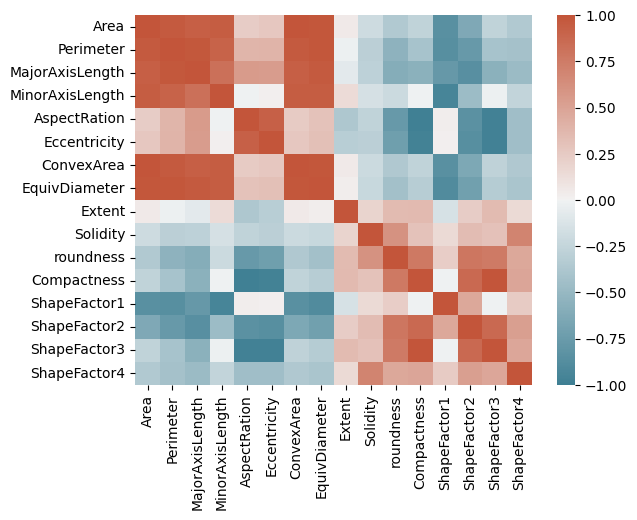

eigenvectors: 
[[ 2.82457959e-01  2.45882017e-01 -6.14466787e-02 -3.15461931e-02
  -9.13256234e-02 -3.66390029e-01  1.25044861e-01  7.17479179e-02
   3.50665669e-02 -3.90419516e-01 -1.77686475e-01  5.44842282e-02
   4.62948861e-02  6.55727948e-01  2.31435926e-01  1.33190281e-01]
 [ 3.10891123e-01  1.79302922e-01 -1.88525952e-02 -4.24678975e-02
   8.18198663e-02 -1.02508210e-02  8.15296990e-02  3.17295058e-02
  -1.57501171e-01  3.44383066e-01  1.99453621e-01 -7.50549982e-01
   3.17920275e-01  8.13901113e-02  1.46143834e-02  1.26584691e-02]
 [ 3.25823976e-01  1.00756516e-01 -8.46919067e-02 -6.79308126e-03
  -4.42163116e-02 -1.49091929e-02  1.18162546e-01 -2.00947006e-01
  -3.52366452e-01  1.01996482e-01  1.73639683e-01  2.73549959e-02
  -6.85301970e-01 -1.86251185e-01  3.46019418e-01  1.74431583e-01]
 [ 2.36199383e-01  3.43460651e-01  7.50039030e-03 -6.12997105e-02
  -4.29258549e-03 -2.78820146e-02 -6.23528140e-02  9.47252766e-02
   4.14230636e-01  4.81150315e-01  4.73720993e-03  4.13935

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data_matrix = pd.read_csv('./data_matrix.csv')

# 1. Use the `.corr()` method on `data_matrix` to get the correlation matrix
correlation_matrix = data_matrix.corr()


## Heatmap code:
red_blue = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(correlation_matrix, vmin=-1, vmax=1, cmap=red_blue)
plt.show()

# 2. Perform eigendecomposition using `np.linalg.eig`
eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)


# 3. Print out the eigenvectors and eigenvalues
print('eigenvectors: ')
print(eigenvectors)

print('eigenvalues: ')
print(eigenvalues)

## Implementing PCA in NumPy II - Analysis

After performing PCA, we want to know how useful the new features are. A **scree plot** shows the proportion of information (variance) each principal component explains.

The proportion of information explained by each component is just its eigenvalue relative to the sum of all eigenvalues:

$$\text{info\_prop} = \frac{\text{eigenvalues}}{\sum \text{eigenvalues}}$$

Plotting `info_prop` against component number gives the scree plot: it typically drops off fast, showing the first few components carry most of the information.

A second, related question: how many principal axes does it take to reach ~95% of the total information? Ideally we retain as few features as possible while still crossing that threshold. Taking the **cumulative sum** of `info_prop` answers this — plot `cum_info_prop` and see where it crosses 0.95.

[5.54664386e-01 2.64309732e-01 8.00656422e-02 5.11408029e-02
 2.73929290e-02 1.14976093e-02 6.97650724e-03 3.25082500e-03
 5.16266295e-04 9.08681206e-05 6.58867938e-05 1.83739336e-05
 9.29966038e-06 6.25641678e-07 1.34132086e-07 1.11549485e-07]


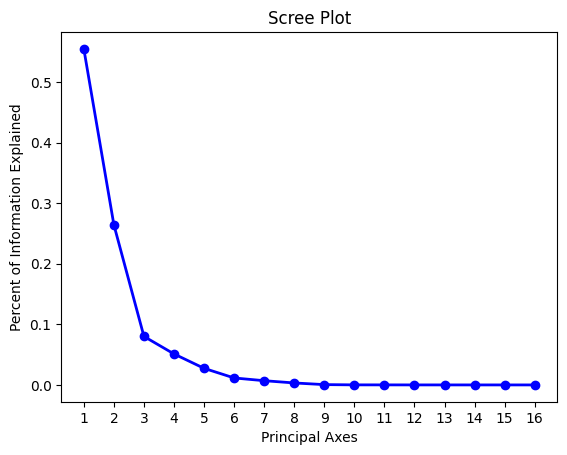

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

eigenvalues = pd.read_csv('eigenvalues.csv')['eigenvalues'].values

# 1. Find the proportion of information for each eigenvector, which is equal to the eigenvalues divided by the sum of all eigenvalues
info_prop = eigenvalues/(eigenvalues.sum())
print(info_prop)

## Plot the principal axes vs the information proportions for each principal axis
plt.plot(np.arange(1,len(info_prop)+1),info_prop, 'bo-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Axes')
plt.xticks(np.arange(1,len(info_prop)+1))
plt.ylabel('Percent of Information Explained')
plt.show()

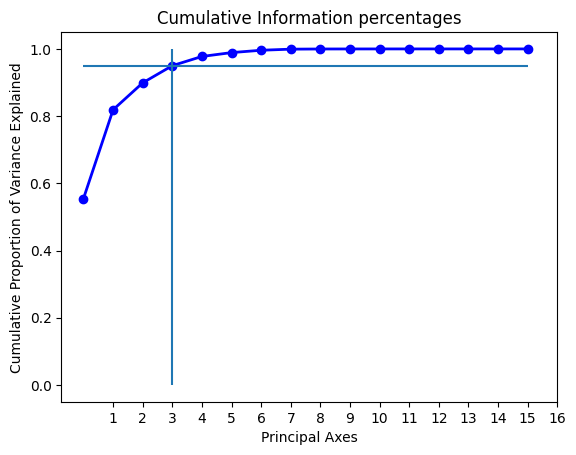

In [13]:
# 2. Find the cumulative sum of the proportions
cum_info_prop = np.cumsum(info_prop)

## Plot the cumulative proportions array
plt.plot(cum_info_prop, 'bo-', linewidth=2)
plt.hlines(y=.95, xmin=0, xmax=15)
plt.vlines(x=3, ymin=0, ymax=1)
plt.title('Cumulative Information percentages')
plt.xlabel('Principal Axes')
plt.xticks(np.arange(1,len(info_prop)+1))
plt.ylabel('Cumulative Proportion of Variance Explained')
plt.show()

## Implementing PCA with scikit-learn

Everything we just did by hand in NumPy — correlation matrix, `np.linalg.eig`, dividing eigenvalues by their sum — `sklearn.decomposition.PCA` does for us in a few lines. Same underlying math, just packaged up.

Three steps:

1. **Standardize the data.** Subtract each column's mean and divide by its standard deviation, so every feature ends up with mean 0 and std 1 — same reasoning as using the *correlation* matrix instead of the covariance matrix earlier (puts features on comparable scales regardless of units).
2. **Fit PCA on the standardized data.** `pca.components_` hands back the **eigenvectors** (principal axes) directly — no manual eigendecomposition needed.
3. **Read off `explained_variance_ratio_`.** This *is* `info_prop` from the scree plot — each eigenvalue's share of the total — already computed for you.

Why bother with sklearn if we can already do it in NumPy? Mainly robustness: sklearn's `PCA` offers several different solvers under the hood for finding the principal axes, which can give more numerically stable results than a plain `eig` call, especially on messy real-world data.

In [14]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

data_matrix = pd.read_csv('./data_matrix.csv')

# 1. Standardize the data matrix
mean = data_matrix.mean(axis=0)
sttd = data_matrix.std(axis=0)
data_matrix_standardized = (data_matrix - mean)/sttd
print(data_matrix_standardized.head())

       Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0 -0.840718  -1.143277        -1.306550        -0.631130     -1.564995   
1 -0.829157  -1.013887        -1.395860        -0.434429     -1.969712   
2 -0.807128  -1.078789        -1.252311        -0.585713     -1.514236   
3 -0.785712  -0.977179        -1.278778        -0.439274     -1.741554   
4 -0.781210  -1.097344        -1.380420        -0.266654     -2.117915   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0     -2.185640   -0.841420      -1.063302  0.289077  0.367600   1.423815   
1     -3.685904   -0.826071      -1.044178  0.697451 -0.462889   0.231046   
2     -2.045261   -0.808674      -1.008047  0.578174  0.518398   1.252819   
3     -2.742110   -0.773947      -0.973301  0.671235 -2.241685   0.515030   
4     -4.534862   -0.784257      -0.966044  0.476003  0.804743   1.874924   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  
0     1.839049     

In [15]:
# 2. Find the principal components
pca = PCA()
components = pca.fit(data_matrix_standardized).components_
components = pd.DataFrame(components).transpose()
components.index = data_matrix.columns
print(components)

                       0         1         2         3         4         5   \
Area             0.282458  0.245882  0.061447 -0.031546  0.091326  0.366390   
Perimeter        0.310891  0.179303  0.018853 -0.042468 -0.081820  0.010251   
MajorAxisLength  0.325824  0.100757  0.084692 -0.006793  0.044216  0.014909   
MinorAxisLength  0.236199  0.343461 -0.007500 -0.061300  0.004293  0.027882   
AspectRation     0.229298 -0.330844  0.169058  0.053646  0.024757 -0.075970   
Eccentricity     0.231526 -0.319434  0.163042  0.118389  0.060304  0.190428   
ConvexArea       0.283200  0.244630  0.053649 -0.030960  0.089113  0.369216   
EquivDiameter    0.297484  0.222802  0.049914 -0.032427  0.021953  0.033515   
Extent          -0.059808  0.220619  0.085258  0.948254 -0.197599 -0.000511   
Solidity        -0.143016  0.103322  0.738670 -0.049546  0.282194 -0.325693   
roundness       -0.248165  0.214805  0.163325  0.067482  0.648701  0.173439   
Compactness     -0.238378  0.328914 -0.149701 -0.087

In [16]:
# 3. Calculate the variance/info ratios
var_ratio = pca.explained_variance_ratio_
var_ratio = pd.DataFrame(var_ratio).transpose()
print(var_ratio)
# -> first four components together account for ~95% of the variance,
#    consistent with the NumPy scree-plot finding earlier

         0        1         2         3         4         5         6   \
0  0.554664  0.26431  0.080066  0.051141  0.027393  0.011498  0.006977   

         7         8         9         10        11        12            13  \
0  0.003251  0.000516  0.000091  0.000066  0.000018  0.000009  6.256417e-07   

             14            15  
0  1.341321e-07  1.115495e-07  


### Q & A — walking through the sklearn code line by line

**Q: Can you break down what each step of the sklearn PCA code is actually doing?**

A:

**The problem it's solving:** doing PCA "by hand" meant building a correlation matrix, calling `np.linalg.eig()` on it, then manually dividing eigenvalues by their sum for the scree-plot percentages — several steps to remember and chain correctly. `sklearn.decomposition.PCA` bundles all of that into an object with a `.fit()` method.

**Step 1 — Standardize the data**
```python
mean = data_matrix.mean(axis=0)
sttd = data_matrix.std(axis=0)
data_standardized = (data_matrix - mean) / sttd
```
Each column gets rescaled to mean 0, std 1. PCA is sensitive to scale — a feature measured in the thousands (`Area`) would dominate a feature measured in decimals (`Eccentricity`) just because of its units, not because it's actually more informative. Same reason the NumPy version used the *correlation* matrix instead of the *covariance* matrix — correlation is just covariance on standardized data. Here the standardization is done explicitly first.

**Step 2 — Fit PCA and pull out the eigenvectors**
```python
pca = PCA()
components = pca.fit(data_standardized).components_
```
`pca.fit(...)` does the eigendecomposition internally — `np.linalg.eig` is never called directly. `.components_` is the eigenvectors, i.e. the **principal axes** — the same thing `eigenvectors` was in the NumPy version. Wrapping it in a DataFrame and setting `.index = data_matrix.columns` labels each row with the original feature name, showing how much each original feature contributes to each new principal-component direction.

**Step 3 — Read off how much each component matters**
```python
var_ratio = pca.explained_variance_ratio_
```
This line **is** the scree-plot data — already the `eigenvalue / sum(eigenvalues)` calculation done by hand as `info_prop`. No cumulative-sum step needed to eyeball it, though `np.cumsum` on this would still answer "how many components to hit 95%?"

**Bottom line:** same math, same result — sklearn does the linear algebra and hands back convenient named attributes (`.components_`, `.explained_variance_ratio_`) instead of assembling them from `np.linalg.eig` output by hand. The one real advantage beyond convenience: sklearn can pick from several different solvers under the hood, which tends to be more numerically stable on messy real data than a single generic `eig` call.

## Projecting the Data onto the Principal Axes

Once eigenvectors are found, the data can be **projected** onto the first few principal axes — either by taking the dot product of the data and the eigenvectors directly, or, more conveniently, via `pca.fit_transform()` with `n_components` capped to however many axes to keep.

```python
pca = PCA(n_components=3)
data_pcomp = pca.fit_transform(data_standardized)
data_pcomp = pd.DataFrame(data_pcomp)
data_pcomp.columns = ['PC1', 'PC2', 'PC3']
```

This is exactly the `.fit_transform()` behavior from earlier: fit the PCA model *and* rotate the data onto the new axes in one call. The difference from before is `n_components` truncates the output to just the top few principal components (instead of all 16), so `data_pcomp` comes back with only that many columns.

Plotting the first two components (`PC1` vs `PC2`) as a scatterplot, color-coded by a label column (e.g. `hue='species'`), is a common way to sanity-check that PCA preserved meaningful structure — if the label classes visually cluster apart in just 2 dimensions, PCA captured the variance that matters for distinguishing them.

*Real Codecademy checkpoint below: `data_matrix_standardized.csv` and `classes.csv` (the pre-standardized dry-bean data matrix + its `Class` labels) were downloaded from Codecademy and dropped in this notebook's directory. Since only 4 components are needed to hit ~95% of the variance (per the earlier scree plot), the checkpoint keeps `n_components=4` here rather than 3.*

In [17]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

data_matrix_standardized = pd.read_csv('./data_matrix_standardized.csv')
classes = pd.read_csv('./classes.csv')['Class']

# 1. Transform the data into 4 new features using the first PCs
pca = PCA(n_components=4)
data_pcomp = pca.fit_transform(data_matrix_standardized)
data_pcomp = pd.DataFrame(data_pcomp)
data_pcomp.columns = ['PC1', 'PC2', 'PC3', 'PC4']
print(data_pcomp.head())

        PC1       PC2       PC3       PC4
0 -4.981378  1.824630 -0.748993 -0.390797
1 -5.436593  2.932257 -2.182294 -0.431944
2 -4.757913  1.826817 -0.514019 -0.125849
3 -4.300383  2.003587 -3.554316  0.082961
4 -6.349107  4.088055 -1.179156 -0.830327


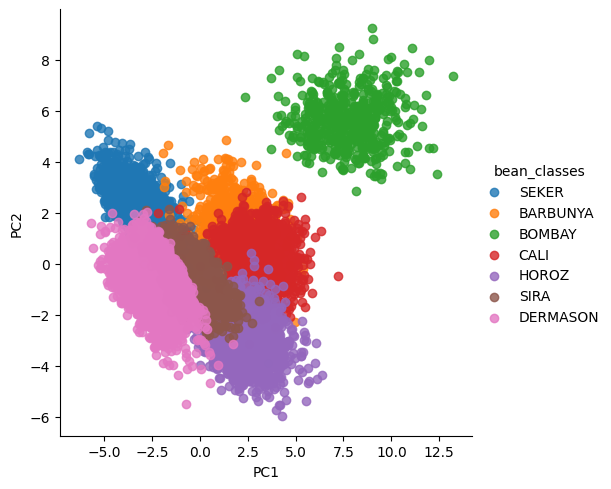

In [18]:
## 2. Plot the first two principal components colored by the bean classes

data_pcomp['bean_classes'] = classes
sns.lmplot(x='PC1', y='PC2', data=data_pcomp, hue='bean_classes', fit_reg=False)
plt.show()
# -> dry bean classes visibly cluster apart using just the first 2 of the 4 kept principal components

## PCA as Features

Beyond visualization, the projected data itself can be used as **training data for a model** — a subset of the principal components stands in for the original (higher-dimensional) feature set, while retaining most of its information.

Since the first 4 principal components already capture ~95% of the variance in the dry-bean data (per the earlier scree plot), those 4 components can train a model just as well as the original 16 features would, with two expected advantages:

- **Faster training** — far fewer features (4 vs. 16) means less computation.
- **Potentially better performance** — principal components are, by construction, uncorrelated with each other (recall: eigenvectors of a symmetric covariance/correlation matrix are mutually orthogonal). Feeding a model uncorrelated features avoids the redundancy/multicollinearity that can hurt some models when trained on the original, correlated feature set.

The upcoming checkpoint compares two **Support Vector Classifier (SVC)** models — one trained on the first 4 principal components, one trained on all 16 original features — using **average likelihood** as the evaluation metric (higher = better fit).

In [19]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split


data_matrix_standardized = pd.read_csv('./data_matrix_standardized.csv')
classes = pd.read_csv('./classes.csv')

# We will use the classes as y
y = classes.Class.astype('category').cat.codes

# Get principal components with 4 features and save as X
pca_1 = PCA(n_components=4)
X = pca_1.fit_transform(data_matrix_standardized)

# Split the data into 33% testing and the rest training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Create a Linear Support Vector Classifier
svc_1 = LinearSVC(random_state=0, tol=1e-5)
svc_1.fit(X_train, y_train)

# Generate a score for the testing data
score_1 = svc_1.score(X_test, y_test)
print(f'Score for model with 4 PCA features: {score_1}')

# Split the original data intro 33% testing and the rest training
X_train, X_test, y_train, y_test = train_test_split(data_matrix_standardized, y, test_size=0.33, random_state=42)

# Create a Linear Support Vector Classifier
svc_2 = LinearSVC(random_state=0)
svc_2.fit(X_train, y_train)

# Generate a score for the testing data
score_2 = svc_2.score(X_test, y_test)
print(f'Score for model with original features: {score_2}')

Score for model with 4 PCA features: 0.8472840605520926
Score for model with original features: 0.9171861086375779


**Note on the actual result:** running this real checkpoint code gives `Score for model with 4 PCA features: 0.847` vs. `Score for model with original features: 0.917` — the **16-feature model scores higher**, the opposite of what the lesson text claims ("the score for the model using the first 4 principal components is higher"). A couple of things worth being precise about:

- `LinearSVC.score()` returns **mean accuracy**, not "average likelihood" — the lesson's own wording for this metric is imprecise; `LinearSVC` doesn't expose a likelihood score at all (that'd be more of an `SVC(probability=True)` / log-likelihood concept).
- On this real dry-bean data with `random_state=42`, dropping from 16 features to 4 principal components costs some accuracy rather than gaining it — the general *reasoning* for trying PCA features (faster training, decorrelated inputs) still holds, but it doesn't always translate into a better score in practice. Here it's a real, measurable trade-off: much lower dimensionality for a ~7-point accuracy drop.

## PCA for Images I

PCA doesn't require a tabular dataset of named features — an **image** works just as well as a data matrix: each row is one image, and each column is one pixel's intensity. A small grayscale image with, say, 64×64 pixels becomes a row of 4,096 features.

This exercise uses the **Olivetti Faces** dataset. First step: standardize the images (same mean-0/std-1 standardization used throughout this notebook), then look at the raw face images themselves before doing anything with PCA.

The next exercise transforms this standardized image data with PCA and reconstructs/re-plots faces using only a subset of the principal components — a direct, visual way to see PCA retaining most of the information (recognizable faces) while dropping a lot of the dimensionality (pixels).

Number of features(pixels) per image: 4096
Square image side length: 64


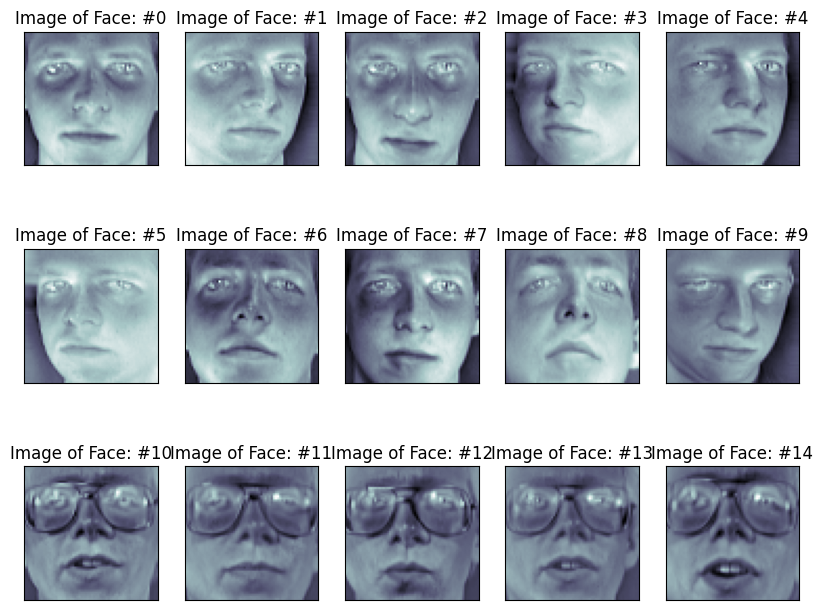

In [20]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt


# Download the data from sklearn's datasets
faces = datasets.fetch_olivetti_faces()['data']

# 1. Standardize the images using the mean and standard deviation
faces_mean = faces.mean(axis=0)
faces_std = faces.std(axis=0)
faces_standardized = (faces - faces_mean) / faces_std


# 2. Find the side length of a square image
n_images, n_features = faces_standardized.shape
side_length = int(np.sqrt(n_features))
print(f'Number of features(pixels) per image: {n_features}')
print(f'Square image side length: {side_length}')


# 3. Plot the first 15 faces
# Create an empty 10x8 plot
fig = plt.figure(figsize=(10, 8))

# Observe the first 15 images.
for i in range(15):

    # Create subplot, remove x and y ticks, and add title
    ax = fig.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
    ax.set_title(f'Image of Face: #{i}')

    # Get an image from a row based on the current value of i
    face_image = faces_standardized[i]

    # Reshape this image into side_length x side_length
    face_image_reshaped = face_image.reshape(side_length, side_length)

    # Show the image
    ax.imshow(face_image_reshaped, cmap=plt.cm.bone)
plt.show()

## PCA for Images II

Running PCA on the standardized face data gives eigenvalues and eigenvectors, same as any other dataset. Here the eigenvectors have their own name: **eigenfaces** — since each "feature" is a pixel, each eigenvector is itself a face-shaped image, and together the eigenfaces are the basic building blocks every other face in the dataset gets constructed from (as a weighted combination).

Two things to visualize:
- **The eigenfaces themselves** — plotting the top eigenvectors directly shows what these "basis faces" look like.
- **Reconstructed faces from a reduced number of components** — instead of just projecting the data (as in the earlier tabular exercises), images can also be projected *back* through the same eigenvectors to reconstruct an approximation of the original face, via `pca.inverse_transform(pca.transform(faces_standardized))`.

The checkpoint has you first run with `n_components=400` (only 0.9% of the original 4096 pixel-features) — reconstructions look nearly identical to the originals. Then it has you drop to `n_components=40` (0.9% of *that*, i.e. ~0.09% of the original pixels) and re-run — reconstructions are still recognizable faces, but visibly lose detail/clarity. The code cell below reflects that second, more aggressive `n_components=40` setting.

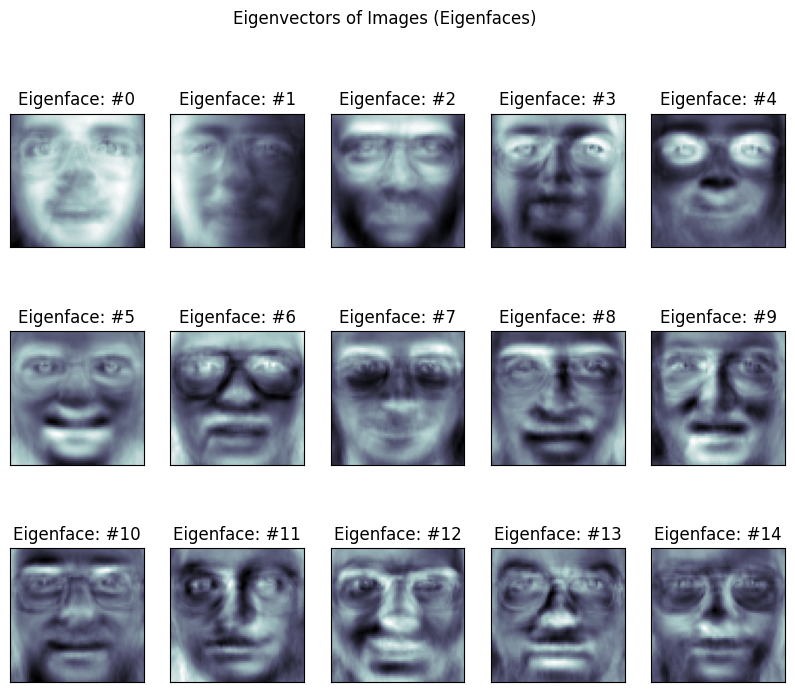

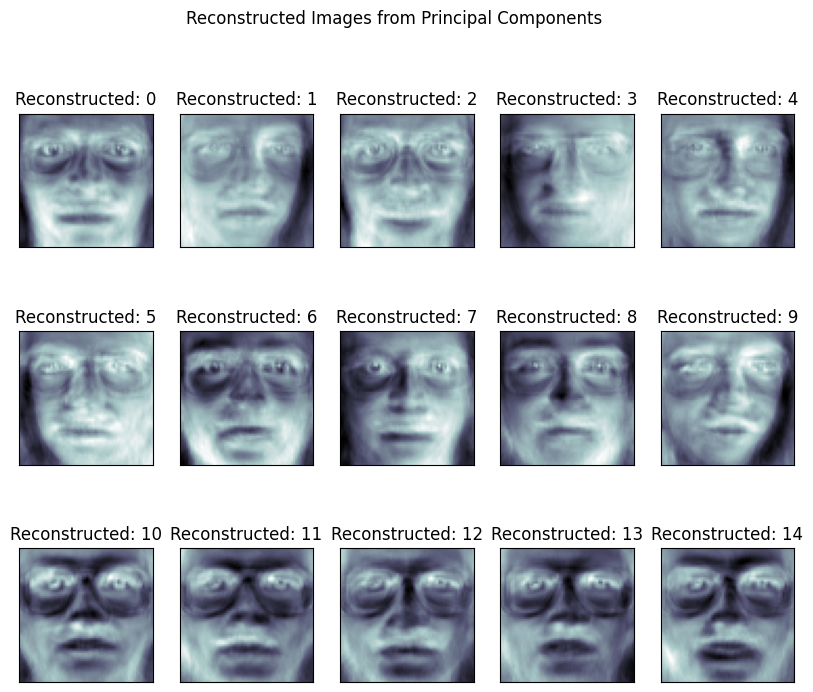

In [21]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


faces_standardized = pd.read_csv('./faces_standardized.csv').values

# 1. Instantiate a PCA object and fit the standardized faces dataset
pca = PCA(n_components=40)
pca.fit(faces_standardized)

# 2. Retrieve and plot eigenvectors (eigenfaces)
eigenfaces = pca.components_

fig = plt.figure(figsize=(10, 8))
fig.suptitle('Eigenvectors of Images (Eigenfaces)')
for i in range(15):
    # Create subplot, remove x and y ticks, and add title
    ax = fig.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
    ax.set_title(f'Eigenface: #{i}')

    # Get an eigenvector from the current value of i
    eigenface = eigenfaces[i]

    # Reshape this image into 64x64 since the flattened shape was 4096
    eigenface_reshaped = eigenface.reshape(64, 64)

    # Show the image
    ax.imshow(eigenface_reshaped, cmap=plt.cm.bone)
plt.show()

# 3. Reconstruct images from the compressed principal components
# The principal components are usually calculated using `faces_standardized @ principal_axes` or the `.transform` method
principal_components = pca.transform(faces_standardized)

# The `inverse_transform` method allows for reconstruction of images in the original size
faces_reconstructed = pca.inverse_transform(principal_components)

# Plot the reconstructed images
fig = plt.figure(figsize=(10, 8))
fig.suptitle('Reconstructed Images from Principal Components')
for i in range(15):
    ax = fig.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
    ax.set_title(f'Reconstructed: {i}')

    reconstructed_face = faces_reconstructed[i]
    reconstructed_face_reshaped = reconstructed_face.reshape(64, 64)
    ax.imshow(reconstructed_face_reshaped, cmap=plt.cm.bone)
plt.show()

## TL;DR

- **PCA reduces the number of features in a dataset without losing most of the information**, by leveraging correlations between features to build a smaller set of new, better features.
- **Variance = information.** A feature with no spread carries no information. The **Coefficient of Variation** (`std/mean * 100`) ranks features by *relative* information regardless of scale.
- **The math:** build a **covariance matrix** (or **correlation matrix** — covariance on standardized/scaled data) from the data matrix, then factor it via eigendecomposition. **Eigenvectors** are the new axes ("directions to rotate the dataset"); **eigenvalues** say how much variance each axis captures. Sorted by eigenvalue, the eigenvectors *are* the **principal components** — each one a linear combination of all original features.
- **Two ways to compute PCA:**
  - **NumPy, by hand:** `df.corr()` (or `.cov()`) → `np.linalg.eig()` → eigenvalues/eigenvectors directly.
  - **sklearn, in a few lines:** standardize the data (`(x - mean) / std`) → `PCA().fit(data).components_` for the eigenvectors → `pca.explained_variance_ratio_` for each component's share of total variance (no manual eigenvalue-sum division needed). sklearn also offers multiple solvers for better numerical stability on messy data.
- **Choosing how many components to keep:** a **scree plot** (`info_prop` / `explained_variance_ratio_` vs. component number) shows a steep drop then a flat tail — look for the elbow. The **cumulative sum** (`np.cumsum`) answers "how many components to reach 95% of the variance?" On the dry-bean dataset (16 features), 4 components hit ~95%.
- **`fit` vs. `transform` vs. `fit_transform`** (general sklearn pattern, not just PCA): `.fit()` learns parameters from data without changing it; `.transform()` applies already-learned parameters to actually change data; `.fit_transform()` does both at once. For PCA specifically, `.transform()` is the **projection** step — dot-producting standardized data onto the eigenvectors to get its new PC-coordinates. Always fit on training data only, then just `.transform()` test/new data, to avoid leaking information.
- **Projecting data onto principal axes:** `PCA(n_components=k).fit_transform(data)` returns the data re-expressed in just the top `k` components. Plotting `PC1` vs `PC2` colored by a known label is a quick visual check that PCA preserved the structure that matters.
- **Using PCA output as model features:** a handful of principal components can replace the full original feature set for training — fewer, and by construction **uncorrelated** (mutually orthogonal eigenvectors), which can mean faster training and sometimes better performance. Real caveat, confirmed on the dry-bean data: this isn't guaranteed — the 16-original-feature `LinearSVC` here actually scored *higher* (0.917) than the 4-PCA-feature version (0.847), despite the lesson claiming the opposite.
- **PCA works on images too** — each pixel is just a feature. The eigenvectors of an image dataset are called **eigenfaces**: face-shaped "basis images" that every other face is a weighted combination of. `pca.inverse_transform(pca.transform(data))` reconstructs approximate originals from a compressed set of components — 400 components (0.9% of 4096 pixels) reconstructs nearly-identical faces; dropping to 40 components still gives recognizable faces but visibly loses detail.
- **Where PCA is used:** preprocessing before feeding high-dimensional data into downstream models; as a standalone unsupervised technique (conceptually similar to clustering, though more often used to *prep* data for a dedicated clustering algorithm); and for compressing image data while retaining most of its visual information.